# Pointwise Judge Preference — Exploratory Analysis

Explores the head-to-head preferences derived from pointwise judge scores in
`output/judge_results_train_api.jsonl` (see `script/compute_pointwise_preference.py`).

For every (question, judge) pair, the two answerer models
(`swiss-ai/Apertus-70B-Instruct-2509` vs `meta-llama/Llama-3.3-70B-Instruct`) are compared
on their **overall score** (mean of accuracy/completeness/topic_coherence/citation_quality,
1-5 scale each). The gap between the two overall scores (0-4 range) determines:

- `tie` — gap == 0
- `weak` preference — 0 < gap < `STRONG_PREFERENCE_THRESHOLD` (1.5)
- `strong` preference — gap >= 1.5 (the judge "completely"/decisively prefers one answer)

Inputs:
- `output/pointwise_preference_comparisons.json` — one row per (question, judge)
- `output/pointwise_preference_consensus.json` — per-question majority vote across the 3 judges
- `output/pointwise_preference_summary.csv` — pre-aggregated stats by judge / judge x regulator / overall
- `output/judge_results_train_api.jsonl` — original records, used here to pull question/answer text for examples

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

BASE = Path("../output")
STRONG_PREFERENCE_THRESHOLD = 1.5

comparisons = json.load(open(BASE / "pointwise_preference_comparisons.json"))
consensus = json.load(open(BASE / "pointwise_preference_consensus.json"))

df = pd.DataFrame(comparisons)
cdf = pd.DataFrame(consensus)

ANSWERERS = sorted(set(df["answerer_1"]) | set(df["answerer_2"]))
JUDGES = sorted(df["judge_model"].unique())

print(f"Comparisons (question x judge): {len(df)}")
print(f"Questions (consensus rows)     : {len(cdf)}")
print(f"Answerer models                : {ANSWERERS}")
print(f"Judge models                    : {JUDGES}")
df.head()

Comparisons (question x judge): 6314
Questions (consensus rows)     : 2134
Answerer models                : ['meta-llama/Llama-3.3-70B-Instruct', 'swiss-ai/Apertus-70B-Instruct-2509']
Judge models                    : ['Qwen/Qwen3.5-27B', 'google/gemma-4-31B-it', 'zai-org/GLM-4.7-Flash']


,question_id,regulator,judge_model,answerer_1,answerer_2,overall_1,overall_2,diff,abs_diff,preferred,preference_strength
0,EBA_2015_1770,EBA,Qwen/Qwen3.5-27B,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,4.5,4.00,0.50,0.50,meta-llama/Llama-3.3-70B-Instruct,weak
1,EBA_2015_1770,EBA,google/gemma-4-31B-it,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,5.0,5.00,0.00,0.00,tie,tie
2,EBA_2015_1770,EBA,zai-org/GLM-4.7-Flash,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,5.0,5.00,0.00,0.00,tie,tie
3,EBA_2015_2051,EBA,Qwen/Qwen3.5-27B,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,3.5,1.75,1.75,1.75,meta-llama/Llama-3.3-70B-Instruct,strong
4,EBA_2015_2051,EBA,google/gemma-4-31B-it,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,3.5,2.00,1.50,1.50,meta-llama/Llama-3.3-70B-Instruct,strong


## 1 · Overview

In [2]:
print("=== Preferred-answer counts (pooled across all judges) ===")
print(df["preferred"].value_counts())
print()

print("=== Preference strength (pooled) ===")
print(df["preference_strength"].value_counts())
print()

summary = pd.read_csv(BASE / "pointwise_preference_summary.csv")
summary

=== Preferred-answer counts (pooled across all judges) ===
preferred
meta-llama/Llama-3.3-70B-Instruct     3623
swiss-ai/Apertus-70B-Instruct-2509    1732
tie                                    959
Name: count, dtype: int64

=== Preference strength (pooled) ===
preference_strength
weak      4652
tie        959
strong     703
Name: count, dtype: int64



,judge_model,mean_abs_diff,n,regulator,strong_preference,strong_preference_rate,ties,weak_preference,wins_meta-llama/Llama-3.3-70B-Instruct,wins_swiss-ai/Apertus-70B-Instruct-2509
0,Qwen/Qwen3.5-27B,0.5328,2134,NaN,151,0.0708,382,1601,1167,585
1,google/gemma-4-31B-it,0.5820,2134,NaN,188,0.0881,349,1597,1259,526
2,zai-org/GLM-4.7-Flash,0.7732,2046,NaN,364,0.1779,228,1454,1197,621
3,Qwen/Qwen3.5-27B,0.5139,1868,EBA,123,0.0658,342,1403,1003,523
4,Qwen/Qwen3.5-27B,0.6654,266,ESMA,28,0.1053,40,198,164,62
5,google/gemma-4-31B-it,0.5739,1868,EBA,159,0.0851,316,1393,1087,465
6,google/gemma-4-31B-it,0.6391,266,ESMA,29,0.1090,33,204,172,61
7,zai-org/GLM-4.7-Flash,0.7629,1796,EBA,310,0.1726,205,1281,1033,558
8,zai-org/GLM-4.7-Flash,0.8470,250,ESMA,54,0.2160,23,173,164,63
9,NaN,0.6273,6314,NaN,703,0.1113,959,4652,3623,1732


## 2 · Win Rate by Judge

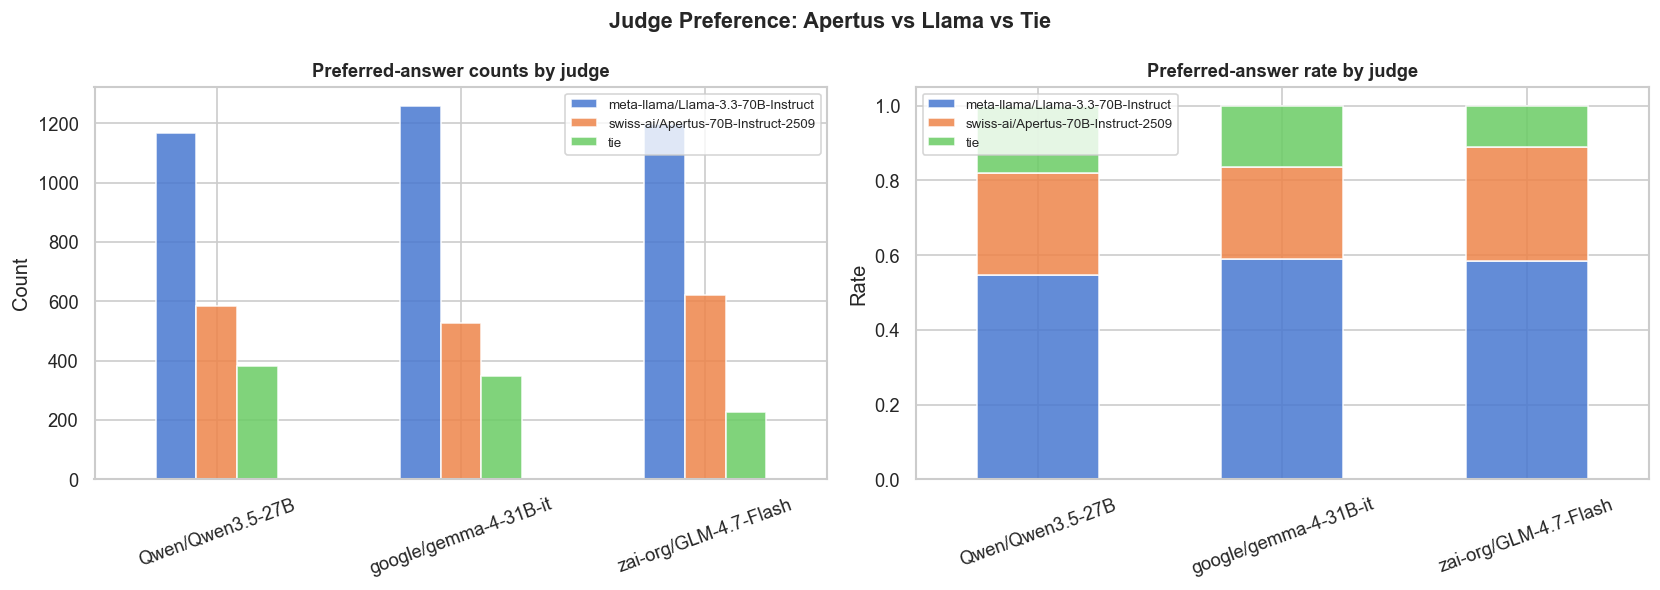

preferred,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,tie
judge_model,,,
Qwen/Qwen3.5-27B,0.547,0.274,0.179
google/gemma-4-31B-it,0.590,0.246,0.164
zai-org/GLM-4.7-Flash,0.585,0.304,0.111


In [3]:
win_counts = (
    df.groupby(["judge_model", "preferred"]).size().unstack(fill_value=0)
)
win_rates = win_counts.div(win_counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
win_counts.plot.bar(ax=axes[0], alpha=0.85)
axes[0].set_title("Preferred-answer counts by judge", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=8)

win_rates.plot.bar(ax=axes[1], alpha=0.85, stacked=True)
axes[1].set_title("Preferred-answer rate by judge", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8)

plt.suptitle("Judge Preference: Apertus vs Llama vs Tie", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

win_rates.round(3)

## 3 · Score-gap Distribution

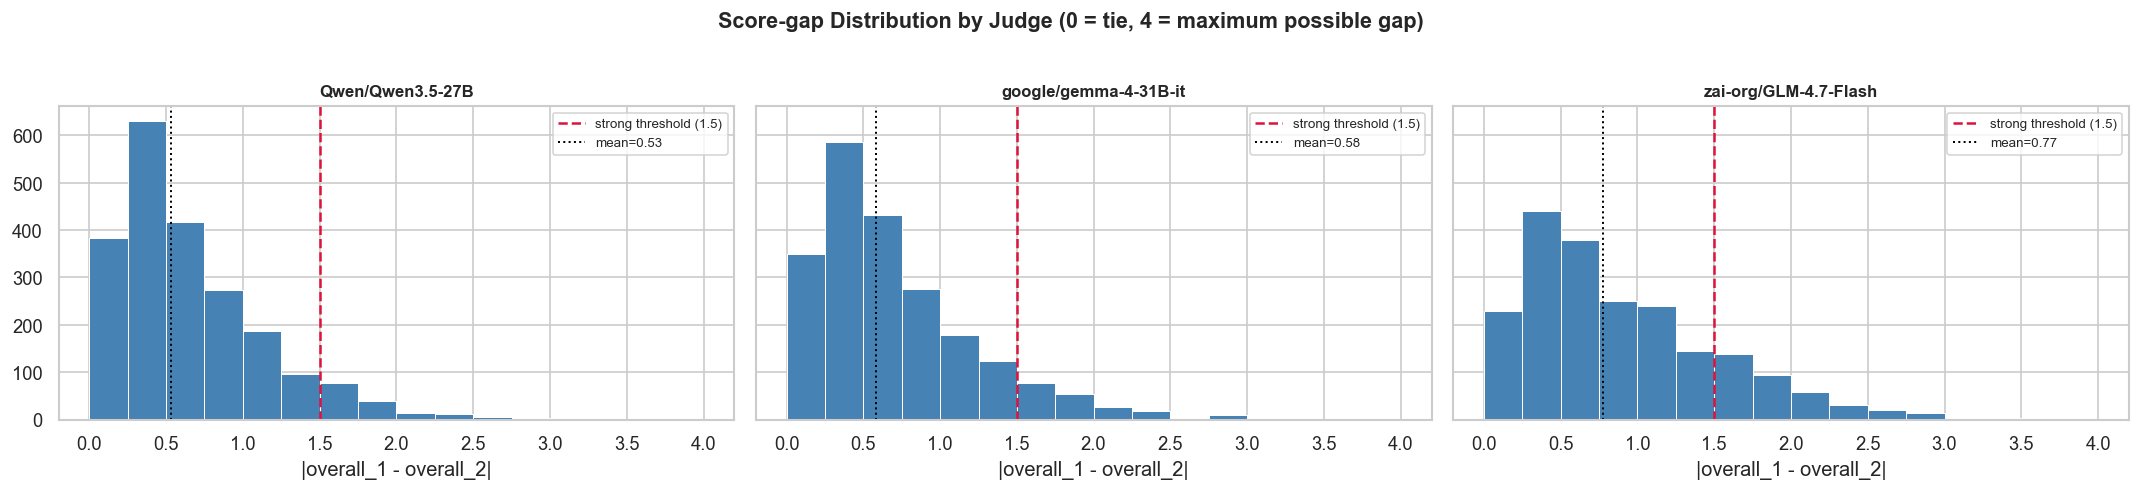

In [4]:
fig, axes = plt.subplots(1, len(JUDGES), figsize=(6 * len(JUDGES), 4), sharey=True)
bins = np.arange(0, 4.01, 0.25)

for ax, judge in zip(axes, JUDGES):
    data = df.loc[df["judge_model"] == judge, "abs_diff"]
    ax.hist(data, bins=bins, color="steelblue", edgecolor="white", linewidth=0.6)
    ax.axvline(STRONG_PREFERENCE_THRESHOLD, color="crimson", linestyle="--", linewidth=1.5,
               label=f"strong threshold ({STRONG_PREFERENCE_THRESHOLD})")
    ax.axvline(data.mean(), color="black", linestyle=":", linewidth=1.2, label=f"mean={data.mean():.2f}")
    ax.set_title(judge, fontsize=10, fontweight="bold")
    ax.set_xlabel("|overall_1 - overall_2|")
    ax.legend(fontsize=8)

plt.suptitle("Score-gap Distribution by Judge (0 = tie, 4 = maximum possible gap)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Preference Strength Breakdown (tie / weak / strong)

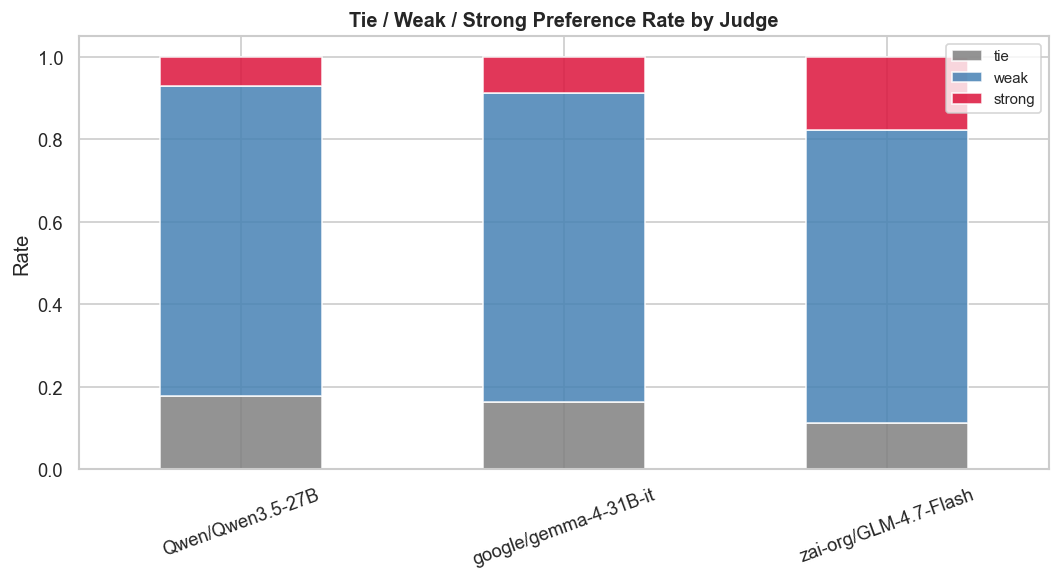

preference_strength,tie,weak,strong
judge_model,,,
Qwen/Qwen3.5-27B,382,1601,151
google/gemma-4-31B-it,349,1597,188
zai-org/GLM-4.7-Flash,228,1454,364


In [5]:
strength_counts = (
    df.groupby(["judge_model", "preference_strength"]).size().unstack(fill_value=0)
)
strength_counts = strength_counts[[c for c in ["tie", "weak", "strong"] if c in strength_counts.columns]]
strength_rates = strength_counts.div(strength_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
strength_rates.plot.bar(ax=ax, stacked=True, color=["grey", "steelblue", "crimson"], alpha=0.85)
ax.set_ylabel("Rate")
ax.set_xlabel("")
ax.set_title("Tie / Weak / Strong Preference Rate by Judge", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="", fontsize=9)
plt.tight_layout()
plt.show()

strength_counts

## 5 · By Regulator (EBA vs ESMA)

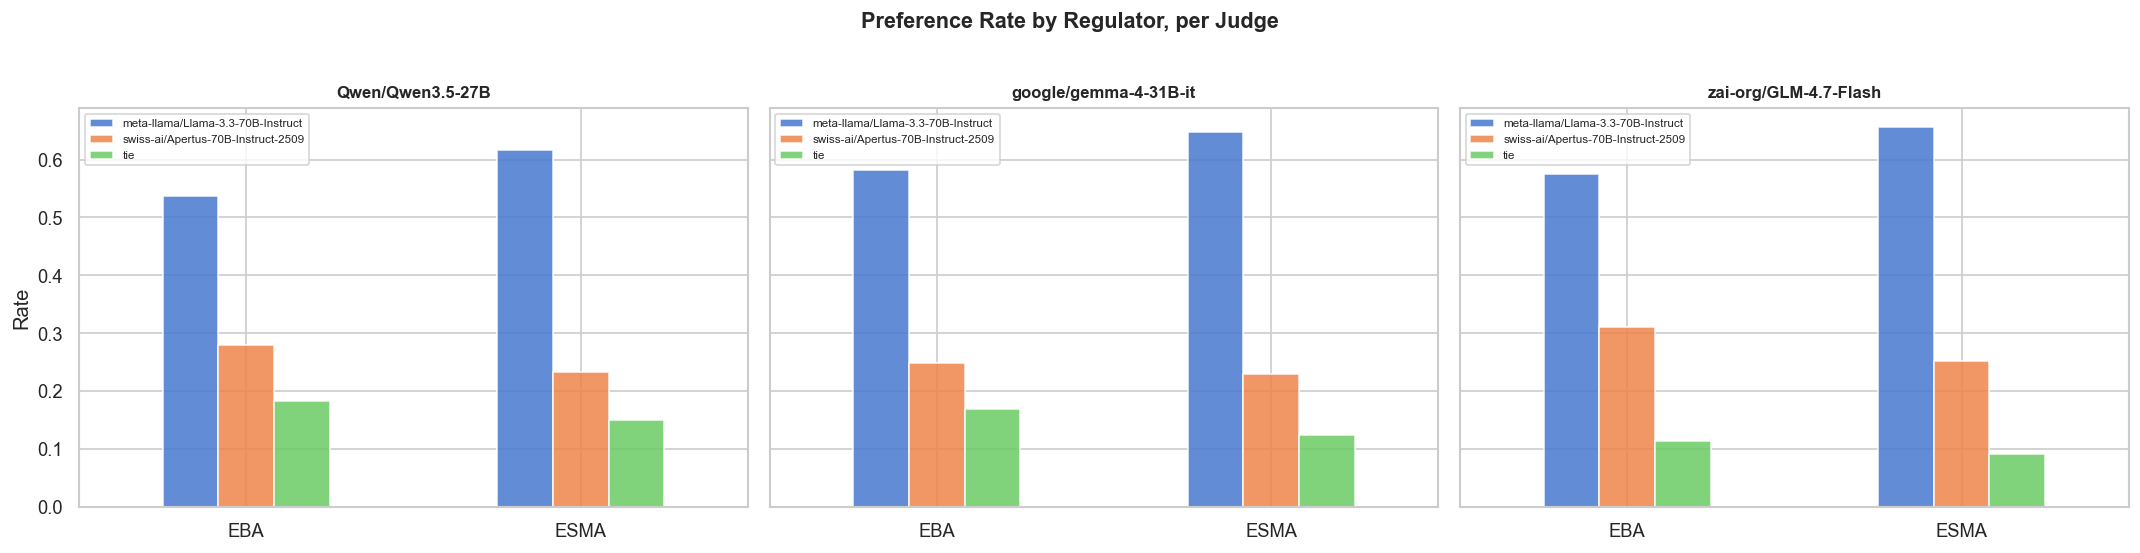

In [6]:
fig, axes = plt.subplots(1, len(JUDGES), figsize=(6 * len(JUDGES), 4.5), sharey=True)

for ax, judge in zip(axes, JUDGES):
    sub = df[df["judge_model"] == judge]
    rates = (
        sub.groupby(["regulator", "preferred"]).size().unstack(fill_value=0)
    )
    rates = rates.div(rates.sum(axis=1), axis=0)
    rates.plot.bar(ax=ax, alpha=0.85)
    ax.set_title(judge, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Rate")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7)

plt.suptitle("Preference Rate by Regulator, per Judge", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6 · Cross-judge Consensus

Questions                                          : 2134
Unanimous (all available judges agree)             : 913 (42.8%)
Unanimous (all 3 judges agree, majority_count == 3): 858 (40.2%)
Unanimous AND all strong preferences               : 52 (2.4%)

Majority-preferred distribution (ties counted as their own category):
majority_preferred
meta-llama/Llama-3.3-70B-Instruct     1283
swiss-ai/Apertus-70B-Instruct-2509     578
tie                                    273
Name: count, dtype: int64

Majority-vote count distribution (3 = unanimous, 2 = 2-1 split, 1 = fully split):
majority_count
1     244
2    1032
3     858
Name: count, dtype: int64


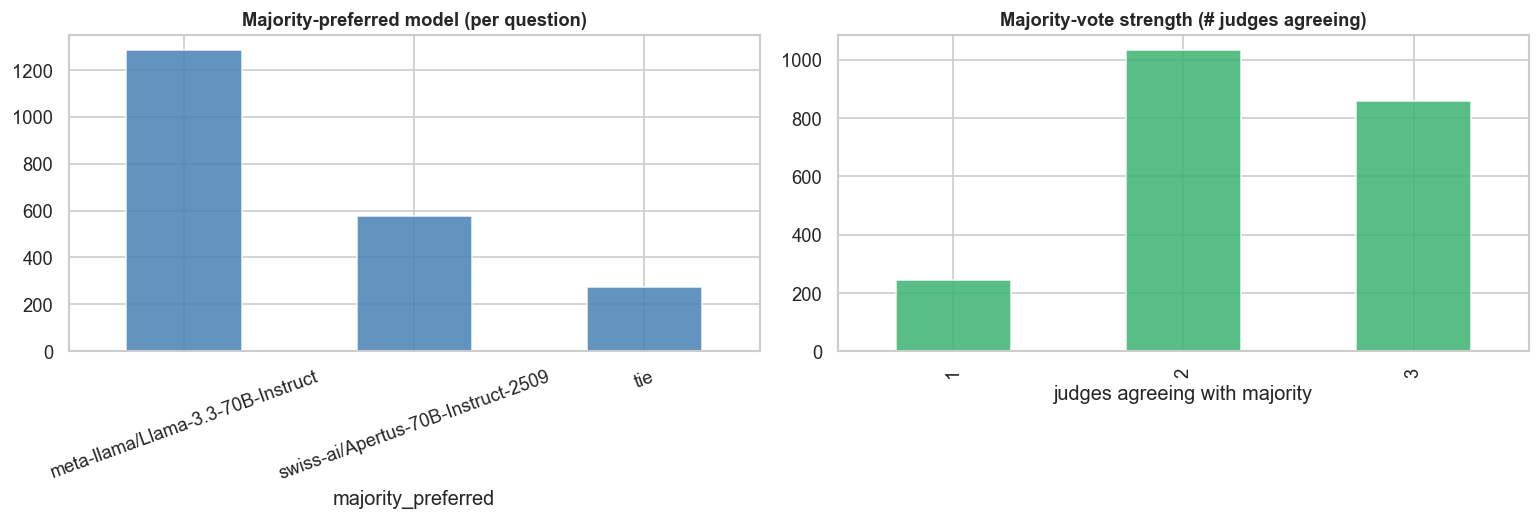

In [2]:
n = len(cdf)
n_unanimous = cdf["unanimous"].sum()
n_unanimous_all3 = (cdf["majority_count"] == 3).sum()
n_unanimous_strong = cdf["unanimous_strong"].sum()

print(f"Questions                                          : {n}")
print(f"Unanimous (all available judges agree)             : {n_unanimous} ({n_unanimous/n*100:.1f}%)")
print(f"Unanimous (all 3 judges agree, majority_count == 3): {n_unanimous_all3} ({n_unanimous_all3/n*100:.1f}%)")
print(f"Unanimous AND all strong preferences               : {n_unanimous_strong} ({n_unanimous_strong/n*100:.1f}%)")
print()
print("Majority-preferred distribution (ties counted as their own category):")
print(cdf["majority_preferred"].value_counts())
print()
print("Majority-vote count distribution (3 = unanimous, 2 = 2-1 split, 1 = fully split):")
print(cdf["majority_count"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cdf["majority_preferred"].value_counts().plot.bar(ax=axes[0], color="steelblue", alpha=0.85)
axes[0].set_title("Majority-preferred model (per question)", fontsize=11, fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

cdf["majority_count"].value_counts().sort_index().plot.bar(ax=axes[1], color="mediumseagreen", alpha=0.85)
axes[1].set_title("Majority-vote strength (# judges agreeing)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("judges agreeing with majority")

plt.tight_layout()
plt.show()

=== Breakdown of unanimous (all 3 judges) by preferred model (n=858) ===
  meta-llama/Llama-3.3-70B-Instruct                 :  655 (76.3%)
  swiss-ai/Apertus-70B-Instruct-2509                :  193 (22.5%)
  tie                                               :   10 (1.2%)


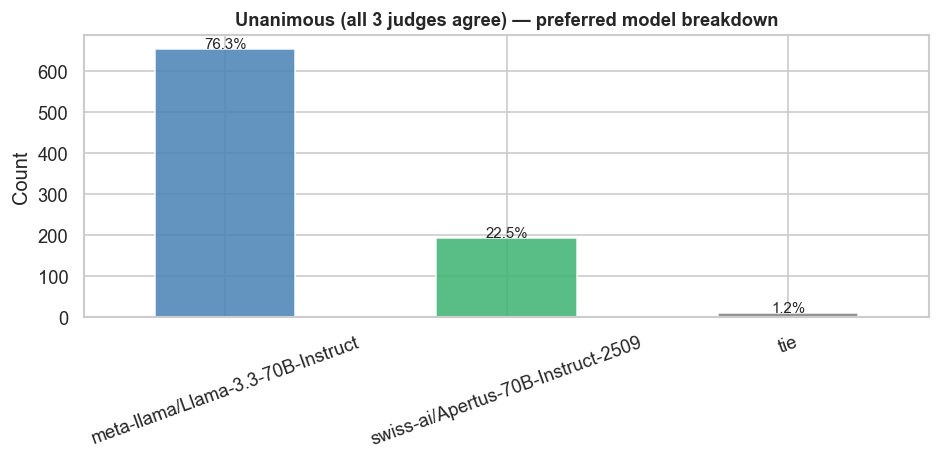

In [3]:
unanimous_all3 = cdf[cdf["majority_count"] == 3]
breakdown = unanimous_all3["majority_preferred"].value_counts()
breakdown_pct = breakdown / len(unanimous_all3) * 100

print(f"=== Breakdown of unanimous (all 3 judges) by preferred model (n={len(unanimous_all3)}) ===")
for model, count in breakdown.items():
    print(f"  {model:50s}: {count:4d} ({breakdown_pct[model]:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
breakdown.plot.bar(ax=ax, color=["steelblue", "mediumseagreen", "grey"][:len(breakdown)], alpha=0.85)
ax.set_title("Unanimous (all 3 judges agree) — preferred model breakdown", fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
for i, (count, pct) in enumerate(zip(breakdown, breakdown_pct)):
    ax.text(i, count + 2, f"{pct:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

=== Mean pooled |diff| distribution (unanimous all-3 questions, n=858) ===
count    858.0000
mean       0.9146
std        0.4651
min        0.0000
25%        0.5833
50%        0.8333
75%        1.1667
max        2.9167
Name: mean_abs_diff, dtype: float64


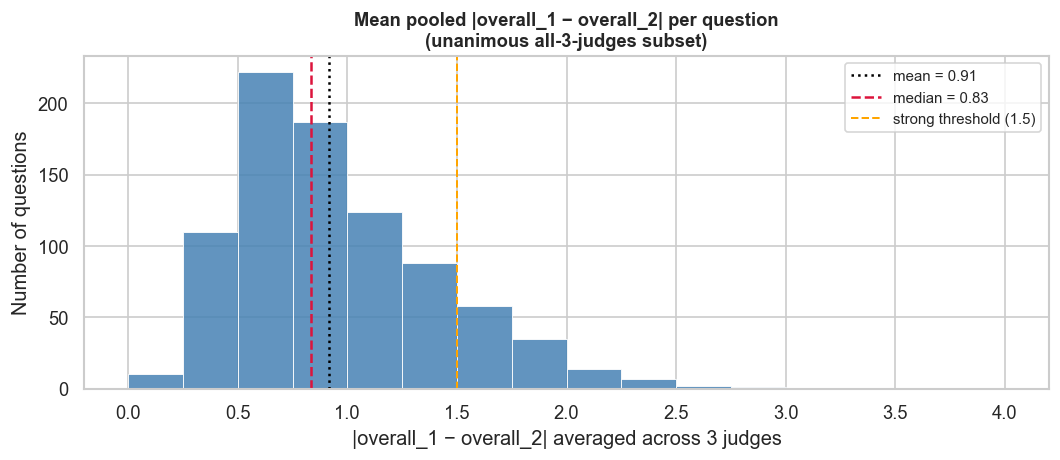

In [4]:
unanimous_qids = set(cdf[cdf["majority_count"] == 3]["question_id"])
unanimous_df = df[df["question_id"].isin(unanimous_qids)]

# Mean pooled abs_diff per question (across the 3 judges)
mean_diff_per_q = unanimous_df.groupby("question_id")["abs_diff"].mean().rename("mean_abs_diff")

print(f"=== Mean pooled |diff| distribution (unanimous all-3 questions, n={len(mean_diff_per_q)}) ===")
print(mean_diff_per_q.describe().round(4))

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(0, 4.01, 0.25)
ax.hist(mean_diff_per_q, bins=bins, color="steelblue", edgecolor="white", linewidth=0.6, alpha=0.85)
ax.axvline(mean_diff_per_q.mean(), color="black", linestyle=":", linewidth=1.5,
           label=f"mean = {mean_diff_per_q.mean():.2f}")
ax.axvline(mean_diff_per_q.median(), color="crimson", linestyle="--", linewidth=1.5,
           label=f"median = {mean_diff_per_q.median():.2f}")
ax.axvline(STRONG_PREFERENCE_THRESHOLD, color="orange", linestyle="--", linewidth=1.2,
           label=f"strong threshold ({STRONG_PREFERENCE_THRESHOLD})")
ax.set_title("Mean pooled |overall_1 − overall_2| per question\n(unanimous all-3-judges subset)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("|overall_1 − overall_2| averaged across 3 judges")
ax.set_ylabel("Number of questions")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

=== Max pooled |diff| distribution (unanimous all-3 questions, n=858) ===
count    858.0000
mean       1.3068
std        0.6322
min        0.0000
25%        0.7500
50%        1.2500
75%        1.7500
max        3.5000
Name: max_abs_diff, dtype: float64


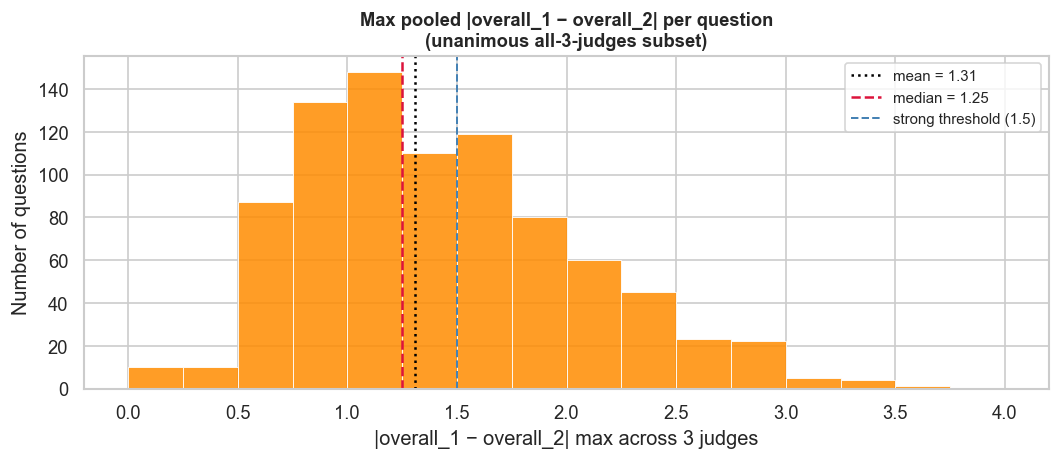

In [5]:
max_diff_per_q = unanimous_df.groupby("question_id")["abs_diff"].max().rename("max_abs_diff")

print(f"=== Max pooled |diff| distribution (unanimous all-3 questions, n={len(max_diff_per_q)}) ===")
print(max_diff_per_q.describe().round(4))

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(0, 4.01, 0.25)
ax.hist(max_diff_per_q, bins=bins, color="darkorange", edgecolor="white", linewidth=0.6, alpha=0.85)
ax.axvline(max_diff_per_q.mean(), color="black", linestyle=":", linewidth=1.5,
           label=f"mean = {max_diff_per_q.mean():.2f}")
ax.axvline(max_diff_per_q.median(), color="crimson", linestyle="--", linewidth=1.5,
           label=f"median = {max_diff_per_q.median():.2f}")
ax.axvline(STRONG_PREFERENCE_THRESHOLD, color="steelblue", linestyle="--", linewidth=1.2,
           label=f"strong threshold ({STRONG_PREFERENCE_THRESHOLD})")
ax.set_title("Max pooled |overall_1 − overall_2| per question\n(unanimous all-3-judges subset)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("|overall_1 − overall_2| max across 3 judges")
ax.set_ylabel("Number of questions")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Max-based Strong Preference

Alternative definition of "strong" unanimous preference: all 3 judges agree on direction **AND** at least one judge has a gap ≥ `STRONG_PREFERENCE_THRESHOLD` (i.e. `max(abs_diff) >= 1.5`).

Compare with the current `unanimous_strong` flag which requires **all 3** judges to individually exceed the threshold.

In [6]:
# Build per-question summary for the unanimous-all-3 subset
unanimous_summary = (
    unanimous_df.groupby("question_id")["abs_diff"]
    .agg(mean_abs_diff="mean", max_abs_diff="max")
    .reset_index()
    .merge(cdf[["question_id", "majority_preferred", "unanimous_strong"]], on="question_id")
)

# Max-based strong: at least one judge >= threshold AND not a tie winner
unanimous_summary["strong_maxbased"] = (
    (unanimous_summary["max_abs_diff"] >= STRONG_PREFERENCE_THRESHOLD) &
    (unanimous_summary["majority_preferred"] != "tie")
)

n_u3 = len(unanimous_summary)
n_all_strong   = unanimous_summary["unanimous_strong"].sum()         # current: all 3 must be strong
n_max_strong   = unanimous_summary["strong_maxbased"].sum()          # new: at least 1 must be strong
n_neither      = (~unanimous_summary["unanimous_strong"] & ~unanimous_summary["strong_maxbased"]).sum()
n_max_not_all  = (unanimous_summary["strong_maxbased"] & ~unanimous_summary["unanimous_strong"]).sum()

print(f"Unanimous all-3 questions                          : {n_u3}")
print(f"Strong (all 3 judges individually strong) [current]: {n_all_strong:4d} ({n_all_strong/n_u3*100:.1f}%)")
print(f"Strong (max-based: at least 1 judge strong) [new]  : {n_max_strong:4d} ({n_max_strong/n_u3*100:.1f}%)")
print(f"  → extra questions unlocked by max-based           : {n_max_not_all:4d}")
print(f"Neither strong under either definition              : {n_neither:4d} ({n_neither/n_u3*100:.1f}%)")

Unanimous all-3 questions                          : 858
Strong (all 3 judges individually strong) [current]:   49 (5.7%)
Strong (max-based: at least 1 judge strong) [new]  :  359 (41.8%)
  → extra questions unlocked by max-based           :  310
Neither strong under either definition              :  499 (58.2%)


=== Preferred model breakdown: current (all 3 strong) ===
majority_preferred
meta-llama/Llama-3.3-70B-Instruct     46
swiss-ai/Apertus-70B-Instruct-2509     3
Name: count, dtype: int64

=== Preferred model breakdown: max-based (at least 1 strong) ===
majority_preferred
meta-llama/Llama-3.3-70B-Instruct     286
swiss-ai/Apertus-70B-Instruct-2509     73
Name: count, dtype: int64


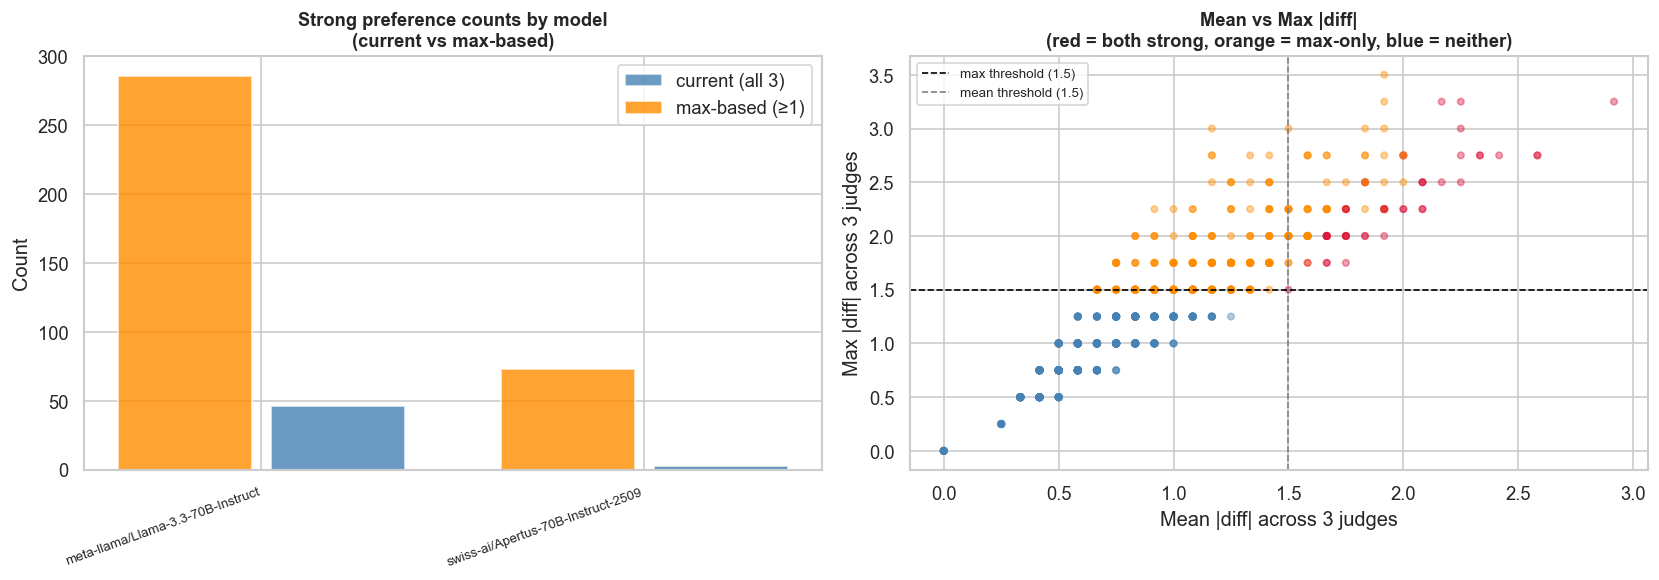

In [7]:
# Breakdown by preferred model under each definition
print("=== Preferred model breakdown: current (all 3 strong) ===")
print(unanimous_summary[unanimous_summary["unanimous_strong"]]["majority_preferred"].value_counts())

print("\n=== Preferred model breakdown: max-based (at least 1 strong) ===")
print(unanimous_summary[unanimous_summary["strong_maxbased"]]["majority_preferred"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: side-by-side counts per model under both definitions
for definition, label, color, pos in [
    ("unanimous_strong", "current (all 3)", "steelblue",  0.2),
    ("strong_maxbased",  "max-based (≥1)",  "darkorange", -0.2),
]:
    counts = unanimous_summary[unanimous_summary[definition]]["majority_preferred"].value_counts()
    x = range(len(counts))
    axes[0].bar([i + pos for i in range(len(counts))], counts.values,
                width=0.35, alpha=0.8, label=label, color=color)
    axes[0].set_xticks(range(len(counts)))
    axes[0].set_xticklabels(counts.index, rotation=20, ha="right", fontsize=8)

axes[0].set_title("Strong preference counts by model\n(current vs max-based)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right: scatter mean vs max diff, coloured by classification
def classify(r):
    if r["unanimous_strong"]:
        return "crimson"       # both definitions → strong
    elif r["strong_maxbased"]:
        return "darkorange"    # max-based only
    else:
        return "steelblue"     # neither

colors = unanimous_summary.apply(classify, axis=1)
axes[1].scatter(unanimous_summary["mean_abs_diff"], unanimous_summary["max_abs_diff"],
                c=colors, alpha=0.4, s=15)
axes[1].axhline(STRONG_PREFERENCE_THRESHOLD, color="black", linestyle="--", linewidth=1,
                label=f"max threshold ({STRONG_PREFERENCE_THRESHOLD})")
axes[1].axvline(STRONG_PREFERENCE_THRESHOLD, color="grey", linestyle="--", linewidth=1,
                label=f"mean threshold ({STRONG_PREFERENCE_THRESHOLD})")
axes[1].set_xlabel("Mean |diff| across 3 judges")
axes[1].set_ylabel("Max |diff| across 3 judges")
axes[1].set_title("Mean vs Max |diff|\n(red = both strong, orange = max-only, blue = neither)",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# Count how many judges gave a strong preference per question
strong_per_q = (
    unanimous_df[unanimous_df["preferred"] != "tie"]
    .groupby("question_id")["preference_strength"]
    .apply(lambda x: (x == "strong").sum())
    .rename("n_strong_judges")
    .reset_index()
)
unanimous_summary2 = unanimous_summary.merge(strong_per_q, on="question_id", how="left")
unanimous_summary2["n_strong_judges"] = unanimous_summary2["n_strong_judges"].fillna(0).astype(int)

# Three definitions
unanimous_summary2["strong_all3"]   = unanimous_summary2["unanimous_strong"]
unanimous_summary2["strong_atleast2"] = (
    (unanimous_summary2["n_strong_judges"] >= 2) &
    (unanimous_summary2["majority_preferred"] != "tie")
)
unanimous_summary2["strong_atleast1"] = unanimous_summary2["strong_maxbased"]

print("=== Strong preference count under each definition (unanimous all-3 subset) ===\n")
for label, col in [
    ("All 3 judges strong     [strictest] ", "strong_all3"),
    ("At least 2 judges strong [middle]   ", "strong_atleast2"),
    ("At least 1 judge strong  [max-based]", "strong_atleast1"),
]:
    n = unanimous_summary2[col].sum()
    print(f"  {label}: {n:4d} / {n_u3}  ({n/n_u3*100:.1f}%)")

print()
print("n_strong_judges distribution (among non-tie unanimous questions):")
non_tie = unanimous_summary2[unanimous_summary2["majority_preferred"] != "tie"]
print(non_tie["n_strong_judges"].value_counts().sort_index())

=== Strong preference count under each definition (unanimous all-3 subset) ===

  All 3 judges strong     [strictest] :   49 / 858  (5.7%)
  At least 2 judges strong [middle]   :  141 / 858  (16.4%)
  At least 1 judge strong  [max-based]:  359 / 858  (41.8%)

n_strong_judges distribution (among non-tie unanimous questions):
n_strong_judges
0    489
1    218
2     92
3     49
Name: count, dtype: int64


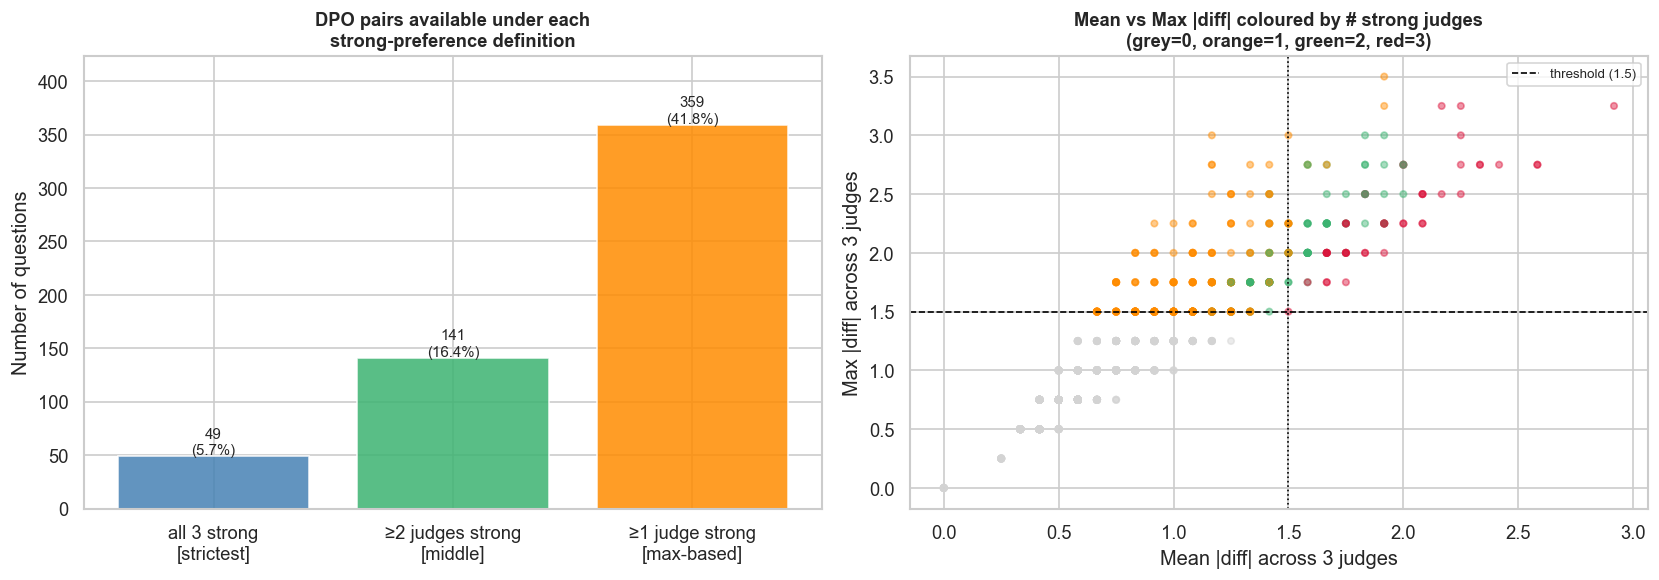

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar comparing counts across 3 definitions
def_labels = ["all 3 strong\n[strictest]", "≥2 judges strong\n[middle]", "≥1 judge strong\n[max-based]"]
def_cols   = ["strong_all3", "strong_atleast2", "strong_atleast1"]
def_colors = ["steelblue", "mediumseagreen", "darkorange"]
counts_bar = [unanimous_summary2[col].sum() for col in def_cols]

bars = axes[0].bar(def_labels, counts_bar, color=def_colors, alpha=0.85)
for bar, count in zip(bars, counts_bar):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 f"{count}\n({count/n_u3*100:.1f}%)", ha="center", fontsize=9)
axes[0].set_title("DPO pairs available under each\nstrong-preference definition",
                  fontsize=11, fontweight="bold")
axes[0].set_ylabel("Number of questions")
axes[0].set_ylim(0, max(counts_bar) * 1.18)

# Right: scatter mean vs max, coloured by n_strong_judges (0/1/2/3)
cmap_colors = {0: "lightgrey", 1: "darkorange", 2: "mediumseagreen", 3: "crimson"}
point_colors = unanimous_summary2["n_strong_judges"].map(cmap_colors).fillna("lightgrey")
axes[1].scatter(unanimous_summary2["mean_abs_diff"], unanimous_summary2["max_abs_diff"],
                c=point_colors, alpha=0.45, s=15)
axes[1].axhline(STRONG_PREFERENCE_THRESHOLD, color="black", linestyle="--", linewidth=1,
                label=f"threshold ({STRONG_PREFERENCE_THRESHOLD})")
axes[1].axvline(STRONG_PREFERENCE_THRESHOLD, color="black", linestyle=":", linewidth=1)
axes[1].set_xlabel("Mean |diff| across 3 judges")
axes[1].set_ylabel("Max |diff| across 3 judges")
axes[1].set_title("Mean vs Max |diff| coloured by # strong judges\n"
                  "(grey=0, orange=1, green=2, red=3)",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

'1 strong judge only' questions: 218

Mean |diff| distribution for this group:
count    218.0000
mean       1.0902
std        0.2398
min        0.6667
25%        0.9167
50%        1.0833
75%        1.2500
max        1.9167
Name: mean_abs_diff, dtype: float64

% with mean |diff| >= 0.75 : 95.4%
% with mean |diff| >= 0.50 : 100.0%
% with mean |diff| <  0.50 : 0.0%


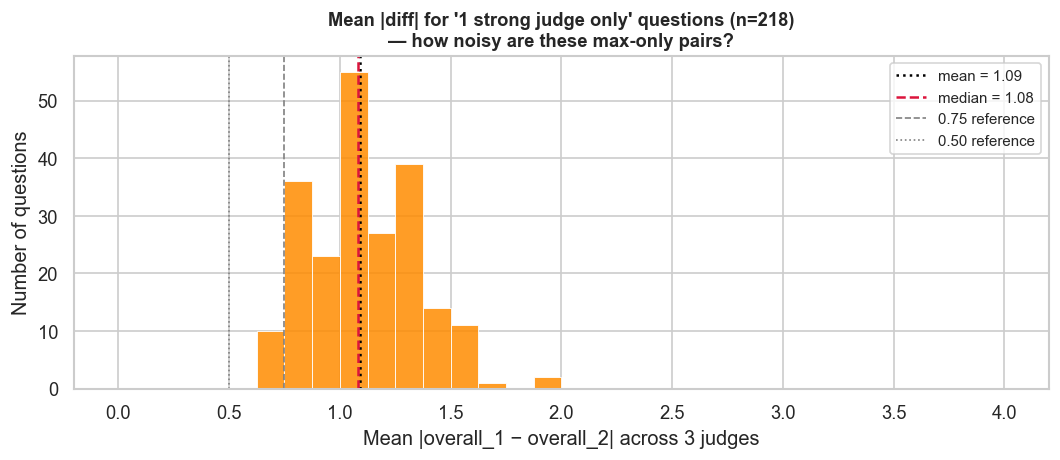

In [10]:
# Questions where exactly 1 judge was strong (the "max-only" group)
only1_strong = unanimous_summary2[unanimous_summary2["n_strong_judges"] == 1]

print(f"'1 strong judge only' questions: {len(only1_strong)}")
print(f"\nMean |diff| distribution for this group:")
print(only1_strong["mean_abs_diff"].describe().round(4))
print(f"\n% with mean |diff| >= 0.75 : {(only1_strong['mean_abs_diff'] >= 0.75).mean()*100:.1f}%")
print(f"% with mean |diff| >= 0.50 : {(only1_strong['mean_abs_diff'] >= 0.50).mean()*100:.1f}%")
print(f"% with mean |diff| <  0.50 : {(only1_strong['mean_abs_diff'] <  0.50).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(0, 4.01, 0.125)
ax.hist(only1_strong["mean_abs_diff"], bins=bins, color="darkorange",
        edgecolor="white", linewidth=0.6, alpha=0.85)
ax.axvline(only1_strong["mean_abs_diff"].mean(), color="black", linestyle=":",
           linewidth=1.5, label=f"mean = {only1_strong['mean_abs_diff'].mean():.2f}")
ax.axvline(only1_strong["mean_abs_diff"].median(), color="crimson", linestyle="--",
           linewidth=1.5, label=f"median = {only1_strong['mean_abs_diff'].median():.2f}")
ax.axvline(0.75, color="grey", linestyle="--", linewidth=1, label="0.75 reference")
ax.axvline(0.50, color="grey", linestyle=":",  linewidth=1, label="0.50 reference")
ax.set_title("Mean |diff| for '1 strong judge only' questions (n=218)\n"
             "— how noisy are these max-only pairs?",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Mean |overall_1 − overall_2| across 3 judges")
ax.set_ylabel("Number of questions")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
DIMS = ["accuracy", "completeness", "topic_coherence", "citation_quality"]

# DPO-ready pairs: unanimous all-3 + max-based strong (at least 1 judge strong, not a tie)
dpo_qids = set(unanimous_summary2[unanimous_summary2["strong_atleast1"]]["question_id"])
dpo_df   = unanimous_df[unanimous_df["question_id"].isin(dpo_qids)].copy()

print(f"DPO-ready pairs (max-based strong, unanimous all-3): {len(dpo_qids)} questions")
print(f"Per-(question, judge) rows                         : {len(dpo_df)}")

# Load raw records if not already in scope
if "records" not in dir():
    records = {}
    with open(BASE / "judge_results_train_api.jsonl") as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                records[rec["question_id"]] = rec

# Extract per-dimension scores from raw records
dim_rows = []
for qid in dpo_qids:
    rec = records.get(qid)
    if rec is None:
        continue
    answers = rec["answers"]
    answerers = sorted(answers.keys())
    if len(answerers) != 2:
        continue
    a1, a2 = answerers
    for judge in JUDGES:
        sc1 = answers[a1]["judge_scores"].get(judge, {})
        sc2 = answers[a2]["judge_scores"].get(judge, {})
        if not sc1 or not sc2:
            continue
        row = {"question_id": qid, "judge_model": judge}
        for d in DIMS:
            v1, v2 = sc1.get(d), sc2.get(d)
            if v1 is not None and v2 is not None:
                row[f"gap_{d}"] = abs(float(v1) - float(v2))
        dim_rows.append(row)

dim_df = pd.DataFrame(dim_rows)

print(f"\nMean absolute gap per dimension (across all DPO-ready question×judge rows):")
gap_means = {}
for d in DIMS:
    col = f"gap_{d}"
    gap_means[d] = dim_df[col].mean()
    print(f"  {d:25s}: mean={gap_means[d]:.4f}  median={dim_df[col].median():.4f}  std={dim_df[col].std():.4f}")

DPO-ready pairs (max-based strong, unanimous all-3): 359 questions
Per-(question, judge) rows                         : 1077

Mean absolute gap per dimension (across all DPO-ready question×judge rows):
  accuracy                 : mean=1.9981  median=2.0000  std=1.2782
  completeness             : mean=1.4605  median=1.0000  std=1.0541
  topic_coherence          : mean=0.9276  median=1.0000  std=0.9767
  citation_quality         : mean=1.2182  median=1.0000  std=1.0550


/var/folders/nc/8j1ss2cd235bsvjlnf8yw7c40000gn/T/ipykernel_12382/1756845838.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gap_long, x="dimension", y="gap", order=order,


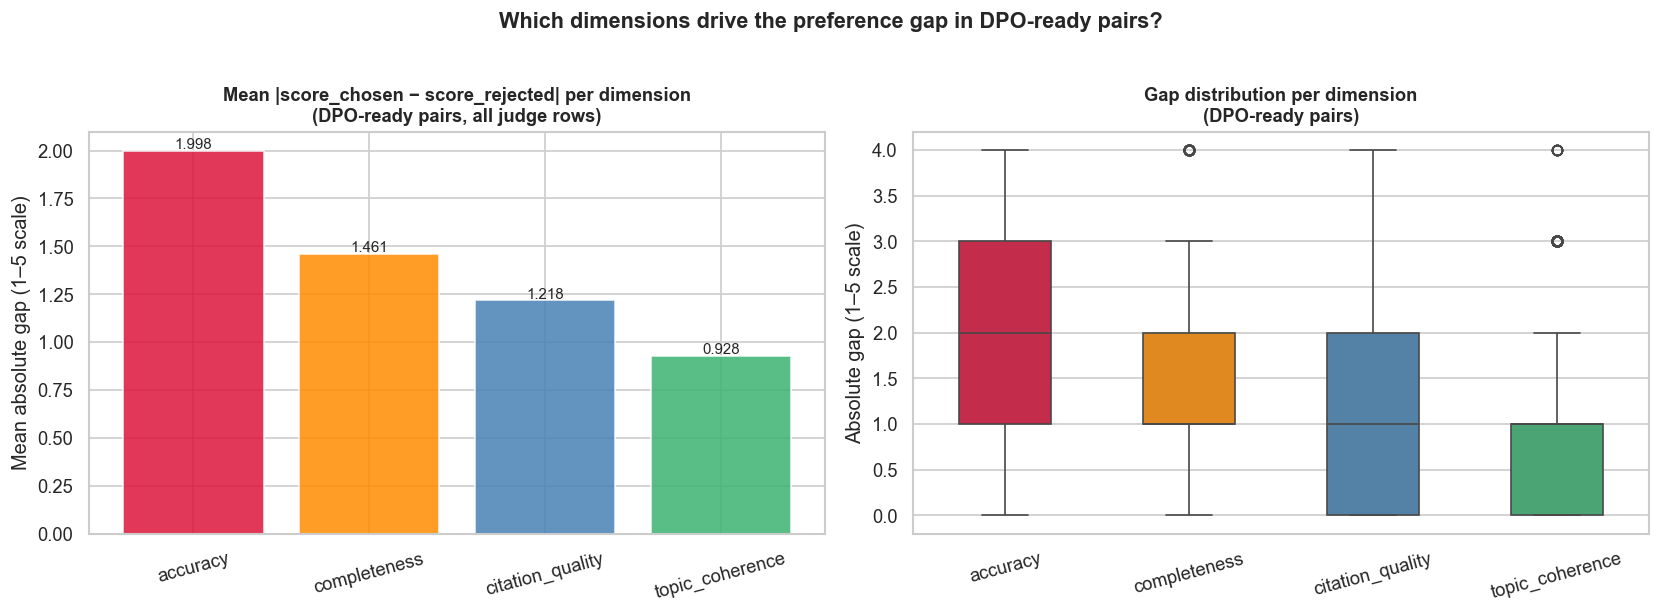

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean gap per dimension, sorted descending
gap_series = pd.Series(gap_means).sort_values(ascending=False)
bar_colors = ["crimson", "darkorange", "steelblue", "mediumseagreen"]
bars = axes[0].bar(gap_series.index, gap_series.values, color=bar_colors[:len(gap_series)], alpha=0.85)
for bar, val in zip(bars, gap_series.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=9)
axes[0].set_title("Mean |score_chosen − score_rejected| per dimension\n(DPO-ready pairs, all judge rows)",
                  fontsize=11, fontweight="bold")
axes[0].set_ylabel("Mean absolute gap (1–5 scale)")
axes[0].tick_params(axis="x", rotation=15)

# Right: boxplot of per-dimension gap distributions
gap_long = dim_df[[f"gap_{d}" for d in DIMS]].rename(
    columns={f"gap_{d}": d for d in DIMS}
).melt(var_name="dimension", value_name="gap")
order = gap_series.index.tolist()
palette = {dim: col for dim, col in zip(order, bar_colors)}
sns.boxplot(data=gap_long, x="dimension", y="gap", order=order,
            palette=palette, ax=axes[1], width=0.5)
axes[1].set_title("Gap distribution per dimension\n(DPO-ready pairs)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Absolute gap (1–5 scale)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Which dimensions drive the preference gap in DPO-ready pairs?",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7 · Examples: Strongest Preferences (biggest score gaps)

In [8]:
# Load original records to pull question / answer text for the examples below
records = {}
with open(BASE / "judge_results_train_api.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            rec = json.loads(line)
            records[rec["question_id"]] = rec


def show_comparison(row, max_len=300):
    rec = records[row["question_id"]]
    a1, a2 = row["answerer_1"], row["answerer_2"]
    ans1 = rec["answers"][a1]["text"]
    ans2 = rec["answers"][a2]["text"]
    reasoning = rec["answers"][a1]["judge_scores"][row["judge_model"]].get("reasoning", {})

    print(f"\n{'='*90}")
    print(f"  [{row['question_id']}]  judge={row['judge_model']}  gap={row['abs_diff']:.2f}  "
          f"preferred={row['preferred']}")
    print(f"{'='*90}")
    print(f"QUESTION     : {rec['question'][:max_len]}")
    print(f"GROUND TRUTH : {rec['ground_truth'][:max_len]}")
    print(f"\n[{a1}]  overall={row['overall_1']}")
    print(f"  {ans1[:max_len]}")
    print(f"\n[{a2}]  overall={row['overall_2']}")
    print(f"  {ans2[:max_len]}")


top_gaps = df.nlargest(3, "abs_diff")
for _, row in top_gaps.iterrows():
    show_comparison(row)


  [EBA_2016_2660]  judge=zai-org/GLM-4.7-Flash  gap=3.50  preferred=meta-llama/Llama-3.3-70B-Instruct
QUESTION     : (a) Can the national competent authority of a Member State grant such exemption where the inflow arises from the parent companies or subsidiaries incorporated in third countries?
(b) If the reply to the first question is positive, shall the national competent authority carry out an assessment as req
GROUND TRUTH : According to Article 33(2)(a) of the Delegated Regulation (EU) 2015/61 subject to prior approval of the competent authority a credit institution may be fully or partially exempted from the cap on inflows (75% of outflows) where the provider is an intragroup entity irrespective of the country of resi

[meta-llama/Llama-3.3-70B-Instruct]  overall=5.0
  According to [Commission Delegated Regulation (EU) 2015/61, Art. 33(2)(a)], a credit institution may be exempted from the cap on inflows where the provider is a parent or a subsidiary within the same group, subjec

## 8 · Examples: Judge Disagreement (split decisions)

Questions where the 3 judges did **not** reach a majority of all 3 (i.e. a 2-1 split or a
fully 1-1-1 split) — these are cases where the pointwise scores genuinely disagree about
which answer is better.

In [9]:
split_decisions = cdf[~cdf["unanimous"]].copy()
print(f"Split-decision questions: {len(split_decisions)} / {len(cdf)} "
      f"({len(split_decisions)/len(cdf)*100:.1f}%)")

# Pick a few fully-split (1-1-1, i.e. majority_count == 1) examples if any exist,
# otherwise fall back to 2-1 splits.
fully_split = split_decisions[split_decisions["majority_count"] == 1]
sample_qids = (fully_split if len(fully_split) else split_decisions).sample(
    min(3, len(split_decisions)), random_state=42
)["question_id"]

for qid in sample_qids:
    rows = df[df["question_id"] == qid]
    rec = records[qid]
    print(f"\n{'='*90}")
    print(f"  [{qid}]")
    print(f"{'='*90}")
    print(f"QUESTION: {rec['question'][:300]}")
    for _, row in rows.iterrows():
        print(f"  judge={row['judge_model']:25s}  preferred={row['preferred']:45s}  "
              f"strength={row['preference_strength']:6s}  gap={row['abs_diff']:.2f}")

Split-decision questions: 1221 / 2134 (57.2%)

  [EBA_2013_576]
QUESTION: How should an institution that uses the standardized approach (for the purpose of calculating the capital requirement for credit risk) determine the exposure value of repurchase transactions with other banks if the collateral provided to the institution doesn’t qualify as eligible according to Artic
  judge=Qwen/Qwen3.5-27B           preferred=tie                                            strength=tie     gap=0.00
  judge=google/gemma-4-31B-it      preferred=meta-llama/Llama-3.3-70B-Instruct              strength=weak    gap=0.25
  judge=zai-org/GLM-4.7-Flash      preferred=swiss-ai/Apertus-70B-Instruct-2509             strength=weak    gap=0.75

  [EBA_2013_204]
QUESTION: It is unlcear from the instructions for the COREP which securtisations exposures should be filled in, in which tab (crsecirb, crsecsa and secdetails).
  judge=Qwen/Qwen3.5-27B           preferred=meta-llama/Llama-3.3-70B-Instruct              